1. Cargar datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

# Este dataset viene separado por espacios, sin encabezado
columnas = ['A1','A2','A3','A4','A5','A6','A7',
            'A8','A9','A10','A11','A12','A13','A14','A15']

df = pd.read_csv('data/australian.dat', sep=' ', names=columnas)

print("✅ Dataset cargado")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

✅ Dataset cargado
Filas: 690, Columnas: 15


2. Vista general

In [2]:
print("=== PRIMERAS FILAS ===")
display(df.head())

print("\n=== TIPOS DE VARIABLES ===")
print(df.dtypes)

numericas   = df.select_dtypes(include='number').columns.tolist()
categoricas = df.select_dtypes(include='object').columns.tolist()
print(f"\nNuméricas: {numericas}")
print(f"Categóricas: {categoricas}")

=== PRIMERAS FILAS ===


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1



=== TIPOS DE VARIABLES ===
A1       int64
A2     float64
A3     float64
A4       int64
A5       int64
A6       int64
A7     float64
A8       int64
A9       int64
A10      int64
A11      int64
A12      int64
A13      int64
A14      int64
A15      int64
dtype: object

Numéricas: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15']
Categóricas: []


3. Valores nulos

In [3]:
nulos = df.isnull().sum()
porcentaje = (nulos / len(df) * 100).round(2)

missing = pd.DataFrame({
    'Valores nulos': nulos,
    'Porcentaje (%)': porcentaje
}).sort_values('Porcentaje (%)', ascending=False)

print("=== VALORES NULOS ===")
print(missing[missing['Valores nulos'] > 0])
print(f"\nTotal nulos: {df.isnull().sum().sum()}")

=== VALORES NULOS ===
Empty DataFrame
Columns: [Valores nulos, Porcentaje (%)]
Index: []

Total nulos: 0


4. Estadísticas descriptivas

In [4]:
df.describe().round(2)

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
count,690.00,690.00,690.00,690.00,690.00,690.00,690.00,690.00,690.00,690.00,690.00,690.00,690.00,690.00,690.00
mean,0.68,31.57,4.76,1.77,7.37,4.69,2.22,0.52,0.43,2.40,0.46,1.93,184.01,1018.39,0.44
std,0.47,11.85,4.98,0.43,3.68,1.99,3.35,0.50,0.50,4.86,0.50,0.30,172.16,5210.10,0.50
min,0.00,13.75,0.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00
25%,0.00,22.67,1.00,2.00,4.00,4.00,0.16,0.00,0.00,0.00,0.00,2.00,80.00,1.00,0.00
50%,1.00,28.62,2.75,2.00,8.00,4.00,1.00,1.00,0.00,0.00,0.00,2.00,160.00,6.00,0.00
75%,1.00,37.71,7.21,2.00,10.00,5.00,2.62,1.00,1.00,3.00,1.00,2.00,272.00,396.50,1.00
max,1.00,80.25,28.00,3.00,14.00,9.00,28.50,1.00,1.00,67.00,1.00,3.00,2000.00,100001.00,1.00


5. Variable objetivo (A15 = 0 rechazado / 1 aprobado)

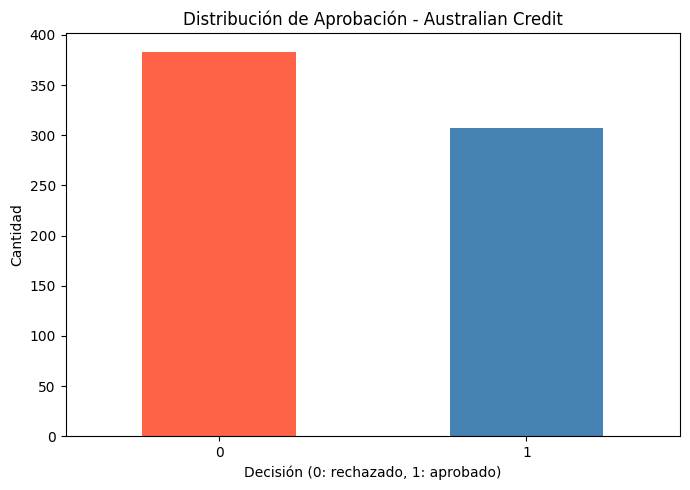

In [5]:
plt.figure(figsize=(7, 5))
df['A15'].value_counts().plot(kind='bar', color=['tomato', 'steelblue'])
plt.title('Distribución de Aprobación - Australian Credit')
plt.xlabel('Decisión (0: rechazado, 1: aprobado)')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

6. Distribuciones de variables clave

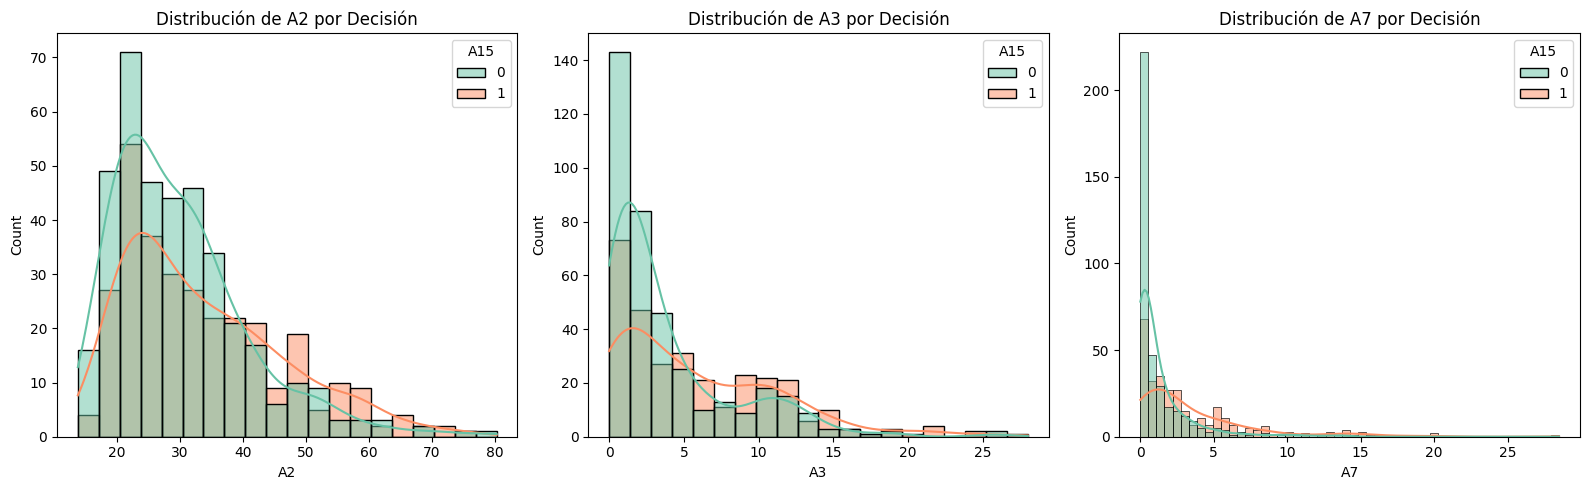

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['A2', 'A3', 'A7']):
    sns.histplot(data=df, x=col, hue='A15',
                 kde=True, palette='Set2', ax=ax)
    ax.set_title(f'Distribución de {col} por Decisión')

plt.tight_layout()
plt.show()

7. Correlaciones

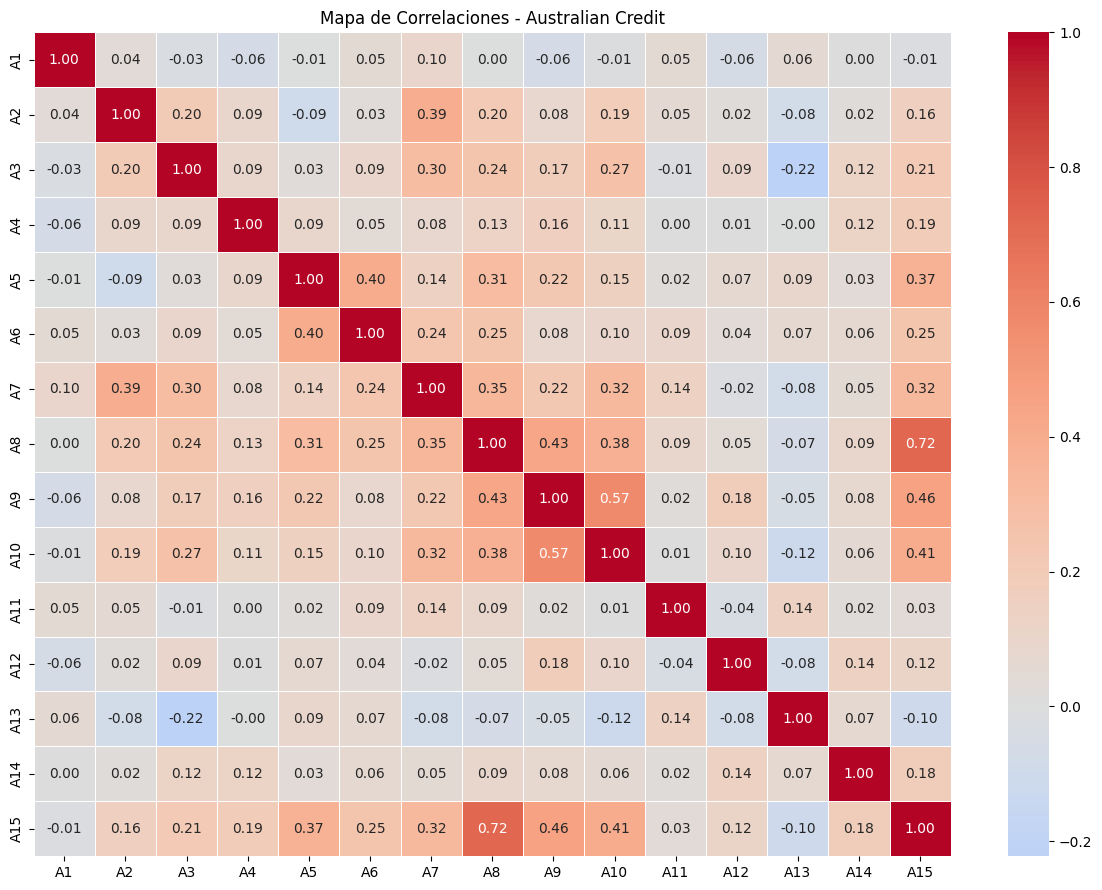

In [7]:
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True,
            fmt='.2f', linewidths=0.5, center=0)
plt.title('Mapa de Correlaciones - Australian Credit')
plt.tight_layout()
plt.show()